In [44]:
import matplotlib.pyplot as plt 
import matplotlib
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text
import numpy as np
from scipy.spatial.distance import jensenshannon
import matplotlib as mpl
import joblib
import pandas as pd
import os
from anndata import AnnData
import scanpy as sc
import cv2
from glob import glob
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

case = "A37"
slide = "WSA_LngSP10193347"
save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759311/cell_ratio.csv").columns)[1:]]

selected_cell_names = ['Basal', 'Ciliated', 'Fibro_adventitial']

In [8]:
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

pred_and_label[slide]['cell_abundance_labels'] = np.clip(pred_and_label[slide]['cell_abundance_labels'], a_min=0, a_max=None)
counts = pred_and_label[slide]['cell_abundance_labels']
coordinates = pred_and_label[slide]['coords']
image = cv2.imread("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/"+slide+"/"+slide+"_lowres.jpg")
adata_cell2location = AnnData(counts, obsm={"spatial": coordinates}, dtype=np.int64)
adata_cell2location.var_names = cell_names
# sc.pp.normalize_total(adata)
# sc.pp.log1p(adata)
spatial_key = "spatial"
library_id = slide
adata_cell2location.uns[spatial_key] = {library_id: {}}
adata_cell2location.uns[spatial_key][library_id]["images"] = {"lowres": image}
adata_cell2location.uns[spatial_key][library_id]["scalefactors"] = {"tissue_hires_scalef": 1, "spot_diameter_fullres": 224.0}

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


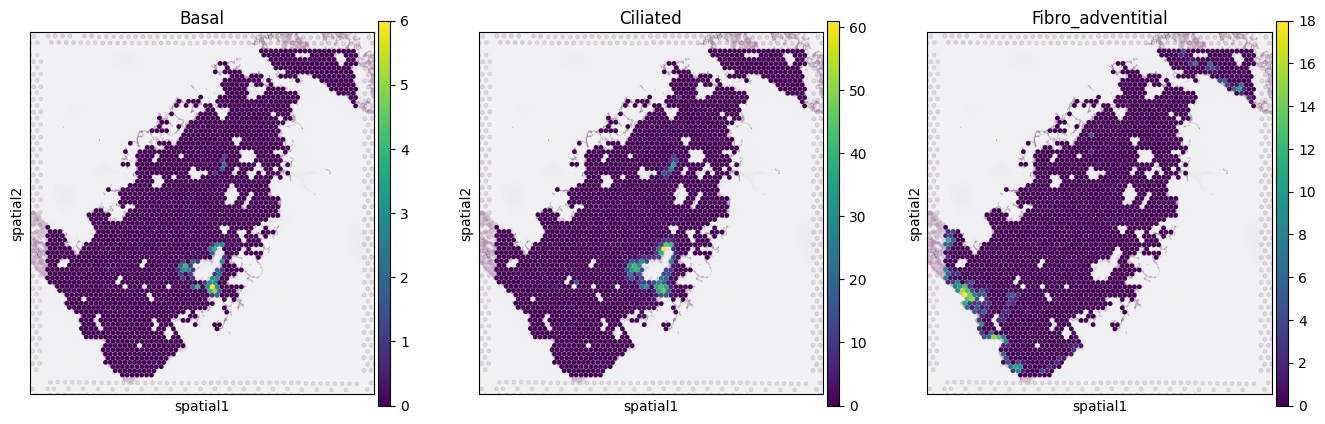

In [51]:
# with mpl.rc_context({'figure.figsize': (10, 10), "font.size": 18}):
with mpl.rc_context({'axes.facecolor':  'black', 'figure.figsize': [4.5, 5]}):
    img = sc.pl.spatial(adata_cell2location, 
                color=selected_cell_names, 
                ncols=3, 
                cmap='viridis',
                size=1.0, 
                img_key='lowres',
                # alpha_img=0.9, 
                # vmin='p0.0', vmax='p99.2',
                return_fig=True,
                scale_factor=0.25,
                )

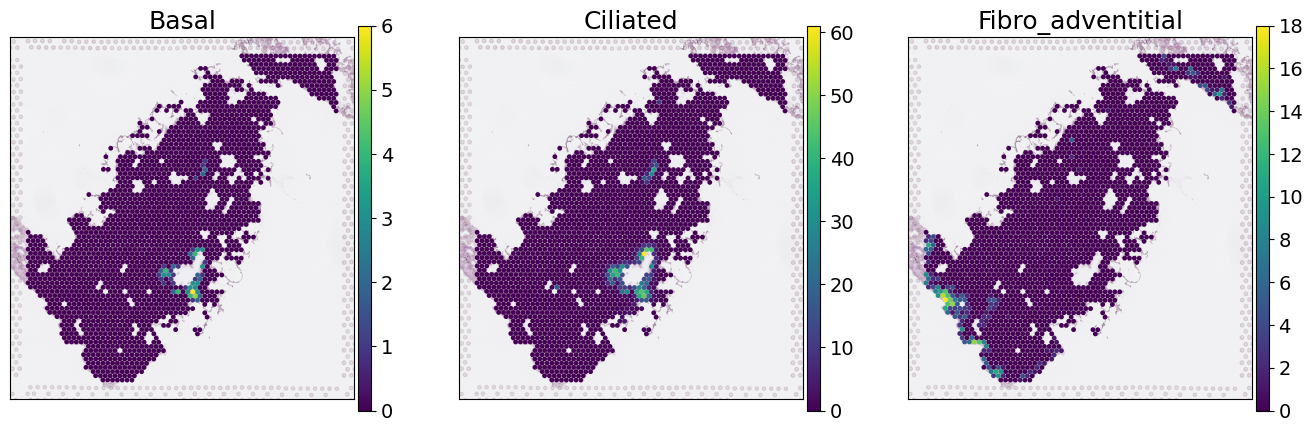

In [61]:
for ax in img:
    ax.set_xlabel('')
    ax.set_ylabel('')
    # 增大title的字体大小
    ax.set_title(ax.get_title(), fontsize=18)

    # 为了增大color bar的刻度字体，您需要先找到color bar对象
    # 这里假设每个ax都有一个color bar
    cbar = ax.collections[0].colorbar
    if cbar:
        cbar.ax.tick_params(labelsize=14)  
        
img[0].figure

In [57]:
img[0].figure.savefig("spatial_plot.pdf", bbox_inches='tight')

In [10]:
pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
counts = pred_and_label[slide]['cell_abundance_predictions']
coordinates = pred_and_label[slide]['coords']
image = cv2.imread("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/"+slide+"/"+slide+"_lowres.jpg")
adata_hist2cell = AnnData(counts, obsm={"spatial": coordinates}, dtype=np.int64)
adata_hist2cell.var_names = cell_names
# sc.pp.normalize_total(adata)
# sc.pp.log1p(adata)
spatial_key = "spatial"
library_id = slide
adata_hist2cell.uns[spatial_key] = {library_id: {}}
adata_hist2cell.uns[spatial_key][library_id]["images"] = {"lowres": image}
adata_hist2cell.uns[spatial_key][library_id]["scalefactors"] = {"tissue_hires_scalef": 1, "spot_diameter_fullres": 224.0}

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


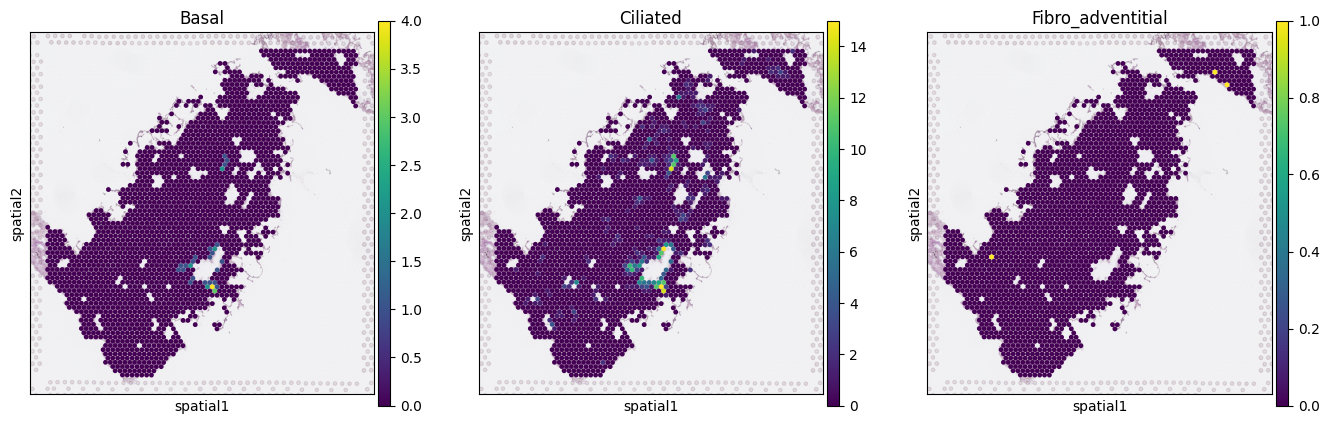

In [40]:
# with mpl.rc_context({'figure.figsize': (10, 10), "font.size": 18}):
with mpl.rc_context({'axes.facecolor':  'black', 'figure.figsize': [4.5, 5]}):
    img = sc.pl.spatial(adata_hist2cell, 
                color=selected_cell_names, 
                ncols=4, 
                cmap='viridis',
                size=1.0, 
                img_key='lowres',
                # alpha_img=0.9, 
                # vmin=0, vmax='p99.9',
                return_fig=True,
                scale_factor=0.25,
                )

In [34]:
save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_densenet_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)

In [37]:
pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
counts = pred_and_label[slide]['cell_abundance_predictions']
coordinates = pred_and_label[slide]['coords']
image = cv2.imread("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/"+slide+"/"+slide+"_lowres.jpg")
adata_stnet = AnnData(counts, obsm={"spatial": coordinates}, dtype=np.int64)
adata_stnet.var_names = cell_names
# sc.pp.normalize_total(adata)
# sc.pp.log1p(adata)
spatial_key = "spatial"
library_id = slide
adata_stnet.uns[spatial_key] = {library_id: {}}
adata_stnet.uns[spatial_key][library_id]["images"] = {"lowres": image}
adata_stnet.uns[spatial_key][library_id]["scalefactors"] = {"tissue_hires_scalef": 1, "spot_diameter_fullres": 224.0}

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


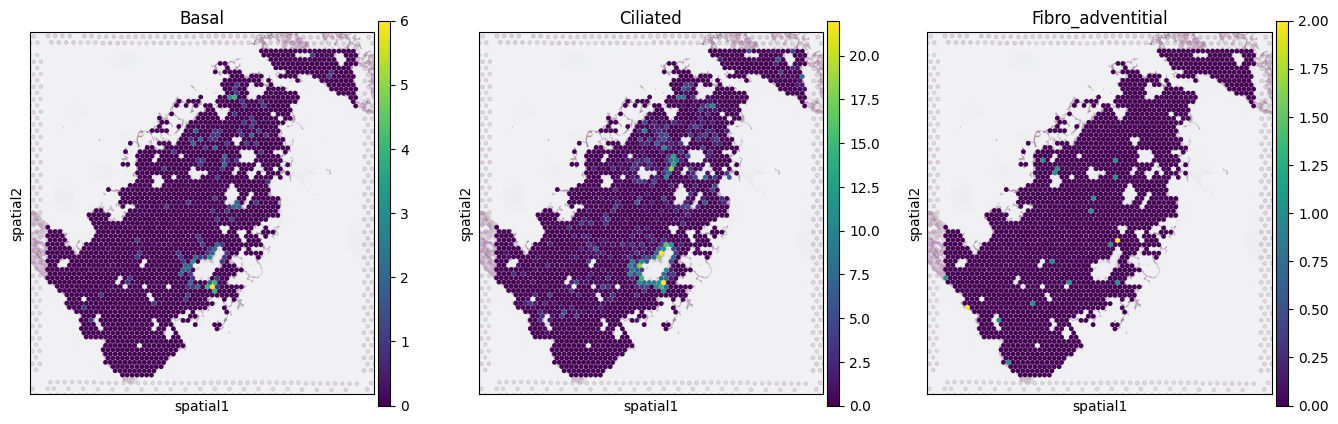

In [39]:
# with mpl.rc_context({'figure.figsize': (10, 10), "font.size": 18}):
with mpl.rc_context({'axes.facecolor':  'black', 'figure.figsize': [4.5, 5]}):
    img = sc.pl.spatial(adata_stnet, 
                color=selected_cell_names, 
                ncols=4, 
                cmap='viridis',
                size=1.0, 
                img_key='lowres',
                # alpha_img=0.9, 
                # vmin=0, vmax='p99.9',
                return_fig=True,
                scale_factor=0.25,
                )

In [9]:
case+"_"+slide+"_"+"cell2loction.png"

'A37_WSA_LngSP10193347_cell2loction.png'

In [24]:
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

input_tif = "/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/"+slide+"/"+slide+".tif"
output_jpg = "/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/"+slide+"/"+slide+".jpg"

# Open the TIFF image
image = Image.open(input_tif)

# Convert the image to JPEG and save it
image.convert("RGB").save(output_jpg, "JPEG")

In [3]:
input_jpg = "/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/"+slide+"/"+slide+".jpg"
output_jpg = "/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/"+slide+"/"+slide+"_lowres.jpg"

# Read the JPEG image
image = cv2.imread(input_jpg)

# Check if the image was read successfully
if image is None:
    print("Error: Failed to load the image.")
else:
    # Get the original dimensions of the image
    height, width = image.shape[:2]

    # Calculate the new dimensions (1/4 of the original size)
    new_width = width // 4
    new_height = height // 4

    # Resize the image
    resized_image = cv2.resize(image, (new_width, new_height))

    # Save the resized image
    cv2.imwrite(output_jpg, resized_image)
    print("Image resized and saved successfully.")

Image resized and saved successfully.


Basal


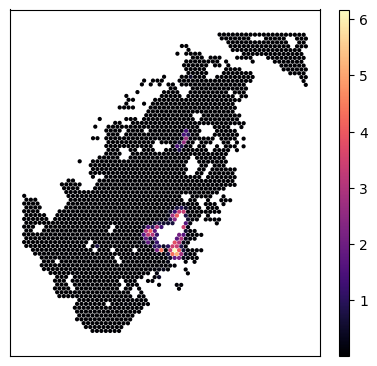

Ciliated


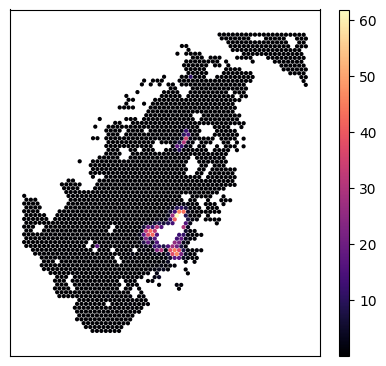

Fibro_adventitial


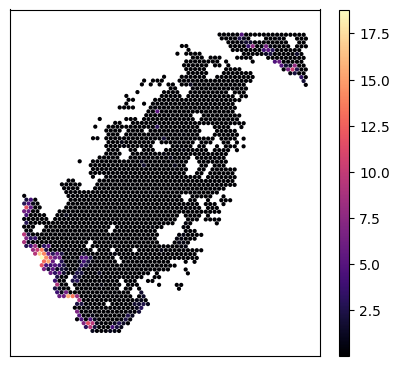

In [47]:
import math
from IPython.core.pylabtools import figsize


case = "A37"
slide = "WSA_LngSP10193347"
selected_cell_names = ['Basal', 'Ciliated', 'Fibro_adventitial']

save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)

pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
pred_ratio = pred_and_label[slide]['cell_abundance_predictions'] / pred_and_label[slide]['cell_abundance_predictions'].sum(axis=1, keepdims=True)
real_ratio = pred_and_label[slide]['cell_abundance_labels'] / pred_and_label[slide]['cell_abundance_labels'].sum(axis=1, keepdims=True)

coordinates = pred_and_label[slide]['coords']
X = coordinates[:, 0]
Y = coordinates[:, 1]

counts = pred_and_label[slide]['cell_abundance_labels']
for i in range(39):
    if cell_names[i] in selected_cell_names:
        print(cell_names[i])
        
        A = counts[:, i]
        # Calculate the minimum distance between points
        min_distance = np.min([math.sqrt((coordinates[i][0] - coordinates[j][0])**2 + (coordinates[i][1] - coordinates[j][1])**2) for i in range(len(coordinates)) for j in range(i+1, len(coordinates))])
        # Set the node size as a fraction of the minimum distance (e.g., 25%)
        node_size = min_distance * 0.018
        # set figure size
        figsize(5, 4.5)
        # Create a scatter plot with a color map
        scatter_plot = plt.scatter(X, Y, c=A, cmap='magma', s=node_size)
        # plt.scatter(X, Y, c=A, cmap='viridis', s=node_size)
        # Add a color bar with the spot values
        # cbar = plt.colorbar()
        cbar = plt.colorbar(scatter_plot, shrink=1.0, aspect=35)
        # cbar.set_label('Cell Abundance')
        # Add title
        # plt.suptitle(cell_names[i], y=0.93)
        # plt.suptitle(cell_names[i])
        # Flip y-axis
        plt.gca().invert_yaxis()
        # Adjust the plot size to match the range of X and Y coordinates
        plt.xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
        plt.ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
        # Show the plot
        plt.axis('equal')
        # plt.axis('off')
        plt.xticks([])
        plt.yticks([])
        # plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung", case, slide, "cell abundance", cell_names[i]+"_Cell2location.png"))
        plt.show()
        plt.close()
        # break

Basal


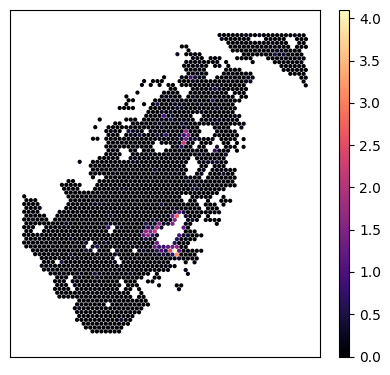

Ciliated


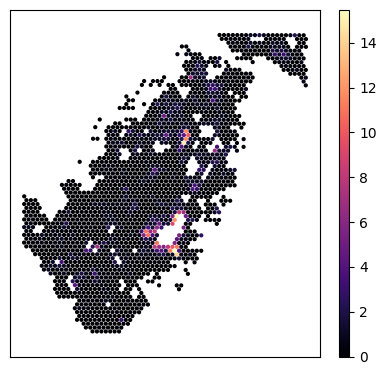

Fibro_adventitial


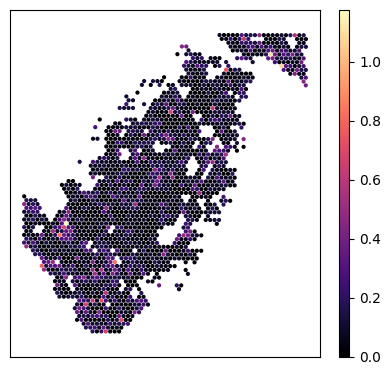

In [48]:
counts = pred_and_label[slide]['cell_abundance_predictions']
for i in range(39):
    if cell_names[i] in selected_cell_names:
        print(cell_names[i])
        
        A = counts[:, i]
        # Calculate the minimum distance between points
        min_distance = np.min([math.sqrt((coordinates[i][0] - coordinates[j][0])**2 + (coordinates[i][1] - coordinates[j][1])**2) for i in range(len(coordinates)) for j in range(i+1, len(coordinates))])
        # Set the node size as a fraction of the minimum distance (e.g., 25%)
        node_size = min_distance * 0.018
        # set figure size
        figsize(5, 4.5)
        # Create a scatter plot with a color map
        scatter_plot = plt.scatter(X, Y, c=A, cmap='magma', s=node_size)
        # plt.scatter(X, Y, c=A, cmap='viridis', s=node_size)
        # Add a color bar with the spot values
        # cbar = plt.colorbar()
        cbar = plt.colorbar(scatter_plot, shrink=1.0, aspect=35)
        # cbar.set_label('Cell Abundance')
        # Add title
        # plt.suptitle(cell_names[i], y=0.93)
        # plt.suptitle(cell_names[i])
        # Flip y-axis
        plt.gca().invert_yaxis()
        # Adjust the plot size to match the range of X and Y coordinates
        plt.xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
        plt.ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
        # Show the plot
        plt.axis('equal')
        # plt.axis('off')
        plt.xticks([])
        plt.yticks([])
        # plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung", case, slide, "cell abundance", cell_names[i]+"_Cell2location.png"))
        plt.show()
        plt.close()

Basal


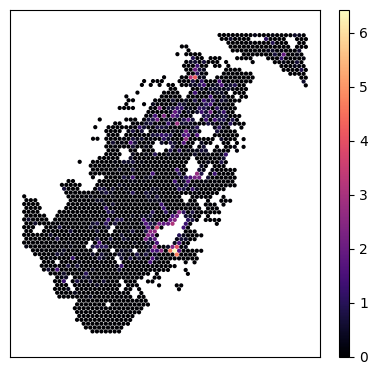

Ciliated


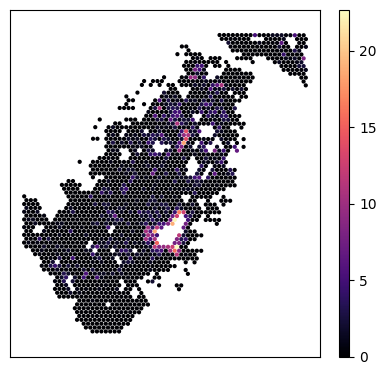

Fibro_adventitial


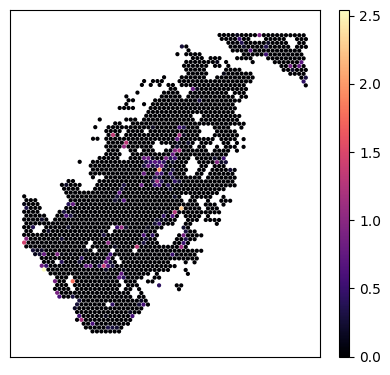

In [46]:
save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_densenet_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)

pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
pred_ratio = pred_and_label[slide]['cell_abundance_predictions'] / pred_and_label[slide]['cell_abundance_predictions'].sum(axis=1, keepdims=True)
real_ratio = pred_and_label[slide]['cell_abundance_labels'] / pred_and_label[slide]['cell_abundance_labels'].sum(axis=1, keepdims=True)

coordinates = pred_and_label[slide]['coords']
X = coordinates[:, 0]
Y = coordinates[:, 1]

counts = pred_and_label[slide]['cell_abundance_predictions']
for i in range(39):
    if cell_names[i] in selected_cell_names:
        print(cell_names[i])
        
        A = counts[:, i]
        # Calculate the minimum distance between points
        min_distance = np.min([math.sqrt((coordinates[i][0] - coordinates[j][0])**2 + (coordinates[i][1] - coordinates[j][1])**2) for i in range(len(coordinates)) for j in range(i+1, len(coordinates))])
        # Set the node size as a fraction of the minimum distance (e.g., 25%)
        node_size = min_distance * 0.018
        # set figure size
        figsize(5, 4.5)
        # Create a scatter plot with a color map
        scatter_plot = plt.scatter(X, Y, c=A, cmap='magma', s=node_size)
        # plt.scatter(X, Y, c=A, cmap='viridis', s=node_size)
        # Add a color bar with the spot values
        # cbar = plt.colorbar()
        cbar = plt.colorbar(scatter_plot, shrink=1.0, aspect=35)
        # cbar.set_label('Cell Abundance')
        # Add title
        # plt.suptitle(cell_names[i], y=0.93)
        # plt.suptitle(cell_names[i])
        # Flip y-axis
        plt.gca().invert_yaxis()
        # Adjust the plot size to match the range of X and Y coordinates
        plt.xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
        plt.ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
        # Show the plot
        plt.axis('equal')
        # plt.axis('off')
        plt.xticks([])
        plt.yticks([])
        # plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung", case, slide, "cell abundance", cell_names[i]+"_Cell2location.png"))
        plt.show()
        plt.close()
        # break

Basal


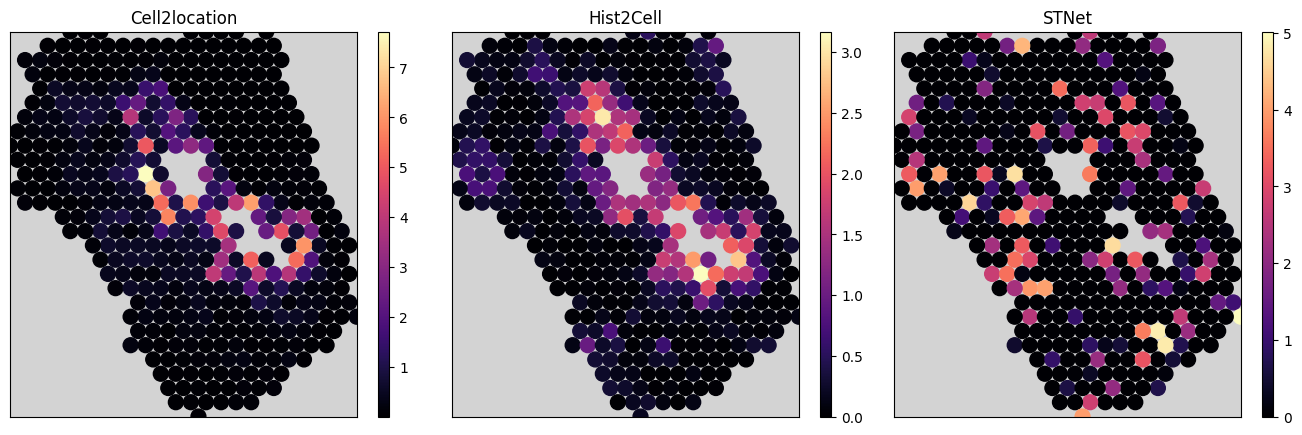

In [69]:
import math
from IPython.core.pylabtools import figsize

case = "A50"
slide = "WSA_LngSP9258467"

save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)
pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
pred_and_label[slide]['cell_abundance_labels'] = np.clip(pred_and_label[slide]['cell_abundance_labels'], a_min=0, a_max=None)

coordinates = pred_and_label[slide]['coords']
X = coordinates[:, 0]
Y = coordinates[:, 1]

cell2location_count2 = pred_and_label[slide]['cell_abundance_labels']
hist2cell_counts = pred_and_label[slide]['cell_abundance_predictions']

save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_densenet_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)
pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)

stnet_counts = pred_and_label[slide]['cell_abundance_predictions']

for i in range(39):
    if cell_names[i] in selected_cell_names:
        print(cell_names[i])
        
        # Calculate the minimum distance between points
        min_distance = np.min([math.sqrt((coordinates[i][0] - coordinates[j][0])**2 + (coordinates[i][1] - coordinates[j][1])**2) for i in range(len(coordinates)) for j in range(i+1, len(coordinates))])
        # Set the node size as a fraction of the minimum distance (e.g., 25%)
        node_size = min_distance * 0.52
        
        
        figsize(17, 5)
        
        # Create subplots for cell2location_count2, hist2cell_counts, and stnet_counts
        fig, axs = plt.subplots(1, 3)
        # Reduce the space between subplots
        plt.subplots_adjust(wspace=0.02)
        
        # Set the background color of each scatter plot to light gray
        axs[0].set_facecolor('lightgray')
        axs[1].set_facecolor('lightgray')
        axs[2].set_facecolor('lightgray')
        
        # cell2location_count2 plot
        scatter_plot1 = axs[0].scatter(X, Y, c=cell2location_count2[:, i], cmap='magma', s=node_size)
        axs[0].invert_yaxis()
        axs[0].set_xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
        axs[0].set_ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
        axs[0].set_xticks([])
        axs[0].set_yticks([])
        axs[0].set_title("Cell2location")
        cbar1 = fig.colorbar(scatter_plot1, ax=axs[0], shrink=1.0, aspect=35)
        
        # hist2cell_counts plot
        scatter_plot2 = axs[1].scatter(X, Y, c=hist2cell_counts[:, i], cmap='magma', s=node_size)
        axs[1].invert_yaxis()
        axs[1].set_xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
        axs[1].set_ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
        axs[1].set_xticks([])
        axs[1].set_yticks([])
        axs[1].set_title("Hist2Cell")
        cbar2 = fig.colorbar(scatter_plot2, ax=axs[1], shrink=1.0, aspect=35)
        
        # stnet_counts plot
        scatter_plot3 = axs[2].scatter(X, Y, c=stnet_counts[:, i], cmap='magma', s=node_size)
        axs[2].invert_yaxis()
        axs[2].set_xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
        axs[2].set_ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
        axs[2].set_xticks([])
        axs[2].set_yticks([])
        axs[2].set_title("STNet")
        cbar3 = fig.colorbar(scatter_plot3, ax=axs[2], shrink=1.0, aspect=35)

        # plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/spatial_visualization/humanlung", case, slide, "cell abundance", cell_names[i]+"_Cell2location.png"))
        plt.show()
        plt.close()
        break

In [21]:
cell2location_count2.shape

(1937, 80)